# metrics-simulation

Feedback loop for testing Graphite alert queries against synthetic time series scenarios.

**Workflow:**
1. Define scenarios (what shapes can this metric take?)
2. Define your alert rule — paste the Graphite query from Grafana
3. Run the simulation
4. Review the summary table and plots
5. Adjust the query and re-run from step 3

In [1]:
import numpy as np
from metrics_simulation import (
    AlertRule, MonteCarloResult,
    simulate, summary, plot_results,
    monte_carlo, mc_summary, plot_monte_carlo,
    scenarios, GraphiteServer,
    ZScoreAlertRule, ZScoreResult, ZScoreMCResult,
    simulate_zscore, zscore_summary, plot_zscore_results,
    monte_carlo_zscore, zscore_mc_summary, plot_zscore_mc,
    parameter_sweep, plot_parameter_sweep,
)

## Graphite server

Start a fresh Graphite container managed by Python.
Call `server.reset()` at any point to wipe all stored metrics and start clean.

In [2]:
server = GraphiteServer()
server.start()

## Step 1: Define scenarios

Each scenario models a different real-world situation for the same metric.
Fix the RNG seed for reproducibility, or remove it for fresh noise each run.

In [3]:
rng = np.random.default_rng(seed=42)

my_scenarios = [
    scenarios.baseline(duration_min=120, rate=0.02, rng=rng),
    scenarios.spike(duration_min=120, spike_at_min=60, spike_value=1.0, rng=rng),
    scenarios.gradual_creep(duration_min=120, creep_start_min=60, end_rate=0.15, rng=rng, phi=1),
    scenarios.zero_drop(duration_min=120, drop_at_min=60, rng=rng),
]

## Step 2: Define your alert rule

Paste the Graphite expression from Grafana into `query`.
Use `{metric}` as a placeholder — it gets substituted with each scenario's metric path at evaluation time.

Example expressions:
- `{metric}` — raw metric, no transformation
- `movingAverage({metric}, 5)` — 5-point moving average
- `summarize({metric}, '5min', 'avg')` — 5-minute bucket average

In [4]:
rule = AlertRule(
    query="{metric}",
    threshold=0.05,
    comparator="gt",
    for_duration_points=1,
)

## Step 3: Run the simulation

Writes each scenario to Graphite, waits briefly for the write to flush, then evaluates the query via the Graphite render API.

In [5]:
results = simulate(rule, my_scenarios, server=server)

## Step 4: Review results

The summary table shows at a glance which scenarios fired and when.
The plot shows the raw data, query output, threshold, and firing windows for each scenario.

In [6]:
summary(results)

,scenario,description,fired,first_fire_min
0,baseline,Stable ~2% error rate. Alert should not fire.,False,NaN
1,spike,Single-point 100% error rate at minute 60. Tes...,True,59.95
2,gradual_creep,Error rate rises from 2% to 15% starting at mi...,False,NaN
3,zero_drop,Error rate (and likely traffic) drops to 0 at ...,False,NaN


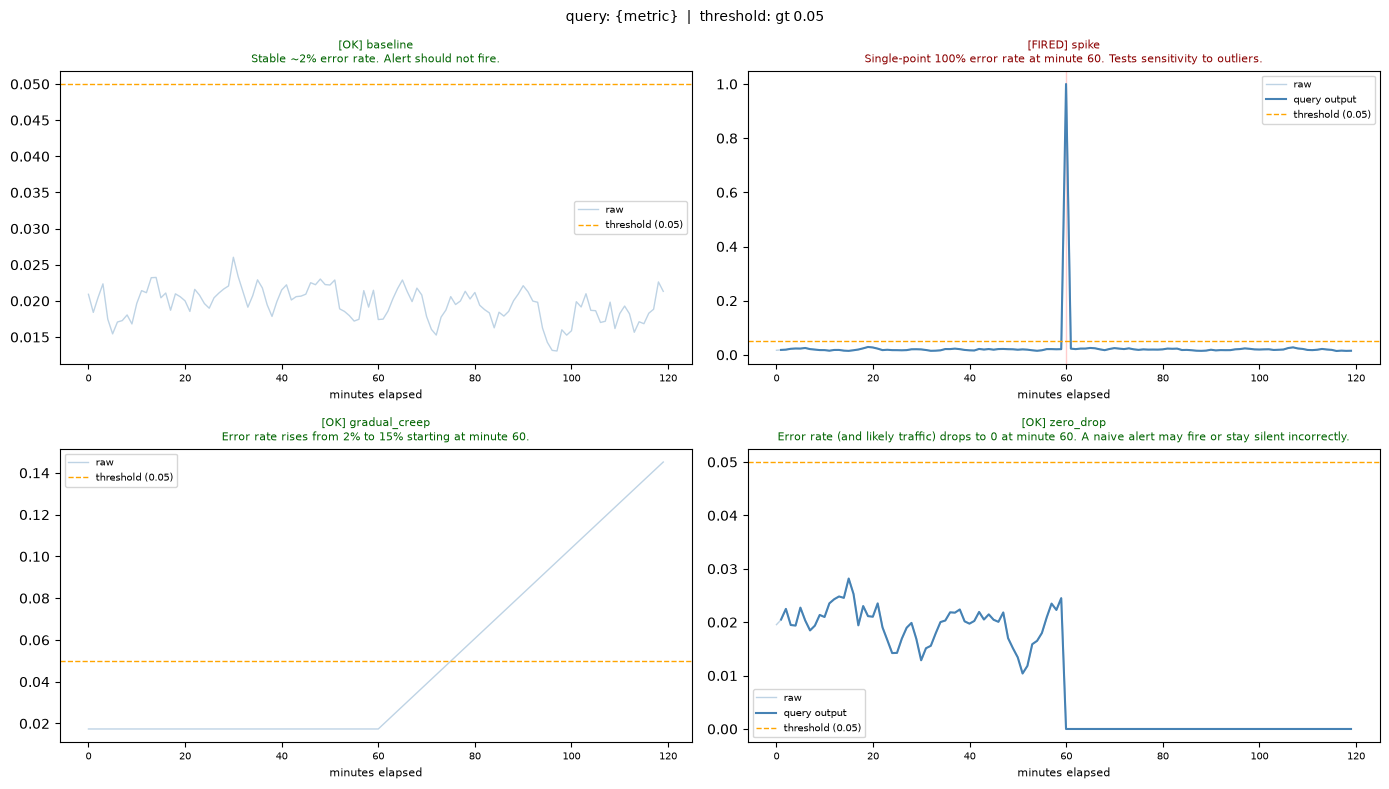

In [7]:
plot_results(results, rule)

---
## Monte Carlo simulation - Example using static threshold alert

Instead of a single run per scenario, Monte Carlo runs each scenario N times with different
noise seeds and reports the *firing rate* across runs.

This answers questions like:
- Does this alert fire on 5% of normal runs? (false positive rate)
- Does it fire on 90% of spike runs? (true positive rate)

Define factories — callables that accept an `rng` and return a `Scenario`.
These are the same generator functions as above, just wrapped so each run gets fresh noise.

In [8]:
factories = [
    lambda rng: scenarios.baseline(duration_min=120, rate=0.02, rng=rng),
    lambda rng: scenarios.spike(duration_min=120, spike_at_min=60, spike_value=1.0, rng=rng),
    lambda rng: scenarios.gradual_creep(duration_min=120, creep_start_min=60, end_rate=0.15, rng=rng),
    lambda rng: scenarios.zero_drop(duration_min=120, drop_at_min=60, rng=rng),
]

In [9]:
mc_results = monte_carlo(
    rule,
    factories,
    server=server,
    n=100,
    seed=42,
)

In [10]:
mc_summary(mc_results)

,scenario,n_runs,fire_rate,median_first_fire_min
0,baseline,100,0.0,None
1,spike,100,0.0,None
2,gradual_creep,100,0.0,None
3,zero_drop,100,0.0,None


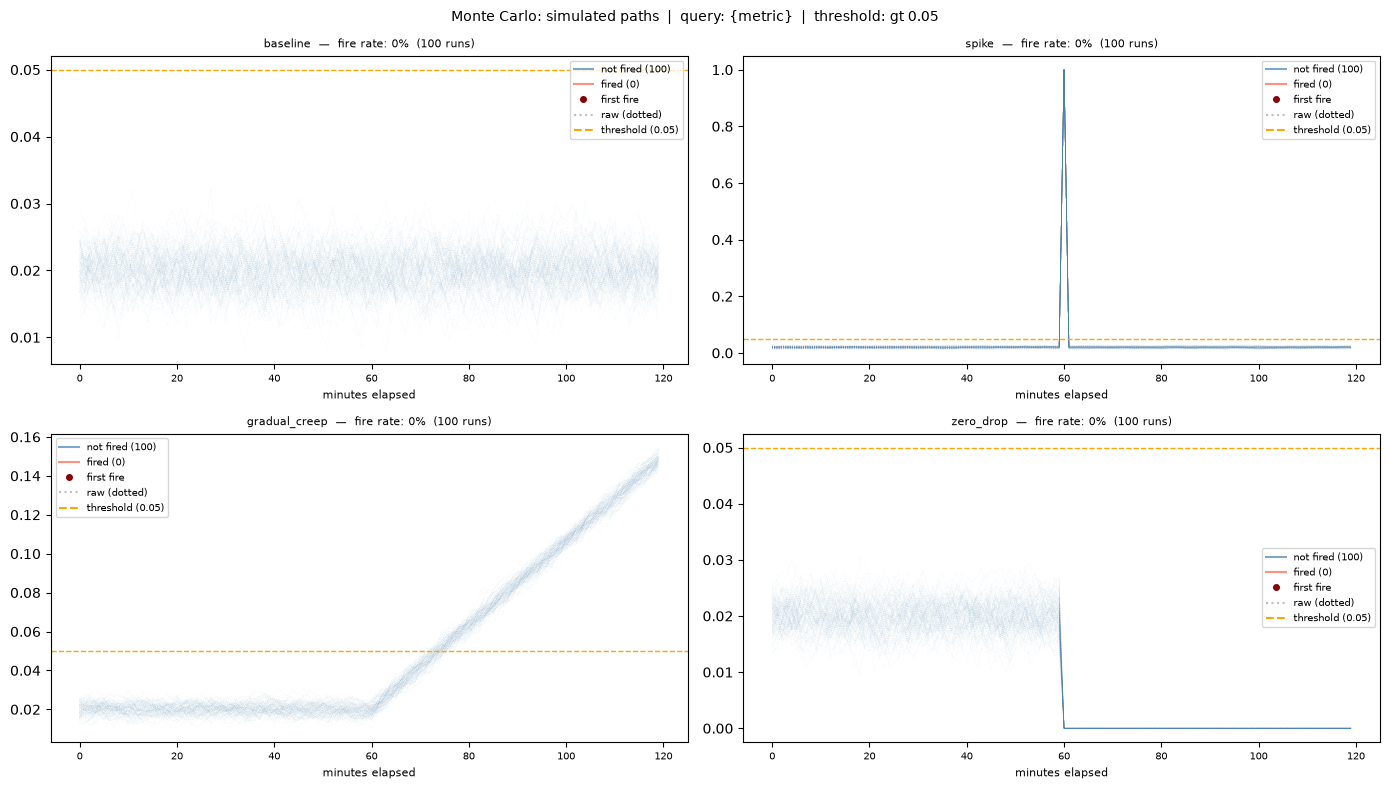

In [11]:
plot_monte_carlo(mc_results, rule)

---
## Z-Score Alert

Instead of a fixed threshold, a z-score alert fires when the metric deviates from its own
rolling baseline by more than N standard deviations — automatically adapting to the metric's
typical level and noise.

| Symbol | Meaning |
|--------|---------|
| **x** | 5-minute rolling mean of the metric (smoothed current value) |
| **μ** | 14-day rolling mean (long-run baseline level) |
| **σ** | 14-day rolling std (long-run baseline variability) |
| **z** | (x − μ) / σ |

**Alert fires when \|z\| > 3** (either direction: sudden spike or sudden drop).

Because the baseline windows are 14 days long, each scenario is extended with a 14-day
burn-in period of normal traffic before the anomalous test window. The z-score alert is
only evaluated during the test window. All computation is pure Python/NumPy — no Graphite
round-trip needed.

In [12]:
BURN_IN_MIN = 14 * 24 * 60  # 20 160 min — fills the 14-day rolling baseline
SIM_MIN = 240               # 4-hour test window; anomaly injected at the midpoint
TOTAL_MIN = BURN_IN_MIN + SIM_MIN
EVENT_MIN = BURN_IN_MIN + SIM_MIN // 2  # absolute minute index where the event fires

rng_zs = np.random.default_rng(seed=42)

zs_scenarios = [
    scenarios.baseline(duration_min=TOTAL_MIN, rate=0.02, rng=rng_zs),
    scenarios.spike(duration_min=TOTAL_MIN, spike_at_min=EVENT_MIN, spike_value=1.0, rng=rng_zs),
    scenarios.gradual_creep(duration_min=TOTAL_MIN, creep_start_min=EVENT_MIN, end_rate=0.15, rng=rng_zs),
    scenarios.zero_drop(duration_min=TOTAL_MIN, drop_at_min=EVENT_MIN, rng=rng_zs),
]

In [13]:
zs_rule = ZScoreAlertRule(
    short_window=5,           # x = 5-minute rolling mean
    long_window=BURN_IN_MIN,  # μ and σ = 14-day rolling mean/std
    sigma_threshold=3.0,
    burn_in_min=BURN_IN_MIN,  # only evaluate alert after the 14-day warm-up
)

In [14]:
zs_results = simulate_zscore(zs_rule, zs_scenarios)

In [15]:
zscore_summary(zs_results)

,scenario,description,fired,first_fire_test_min
0,baseline,Stable ~2% error rate. Alert should not fire.,False,NaN
1,spike,Single-point 100% error rate at minute 20280. ...,True,120.0
2,gradual_creep,Error rate rises from 2% to 15% starting at mi...,True,131.0
3,zero_drop,Error rate (and likely traffic) drops to 0 at ...,True,121.0


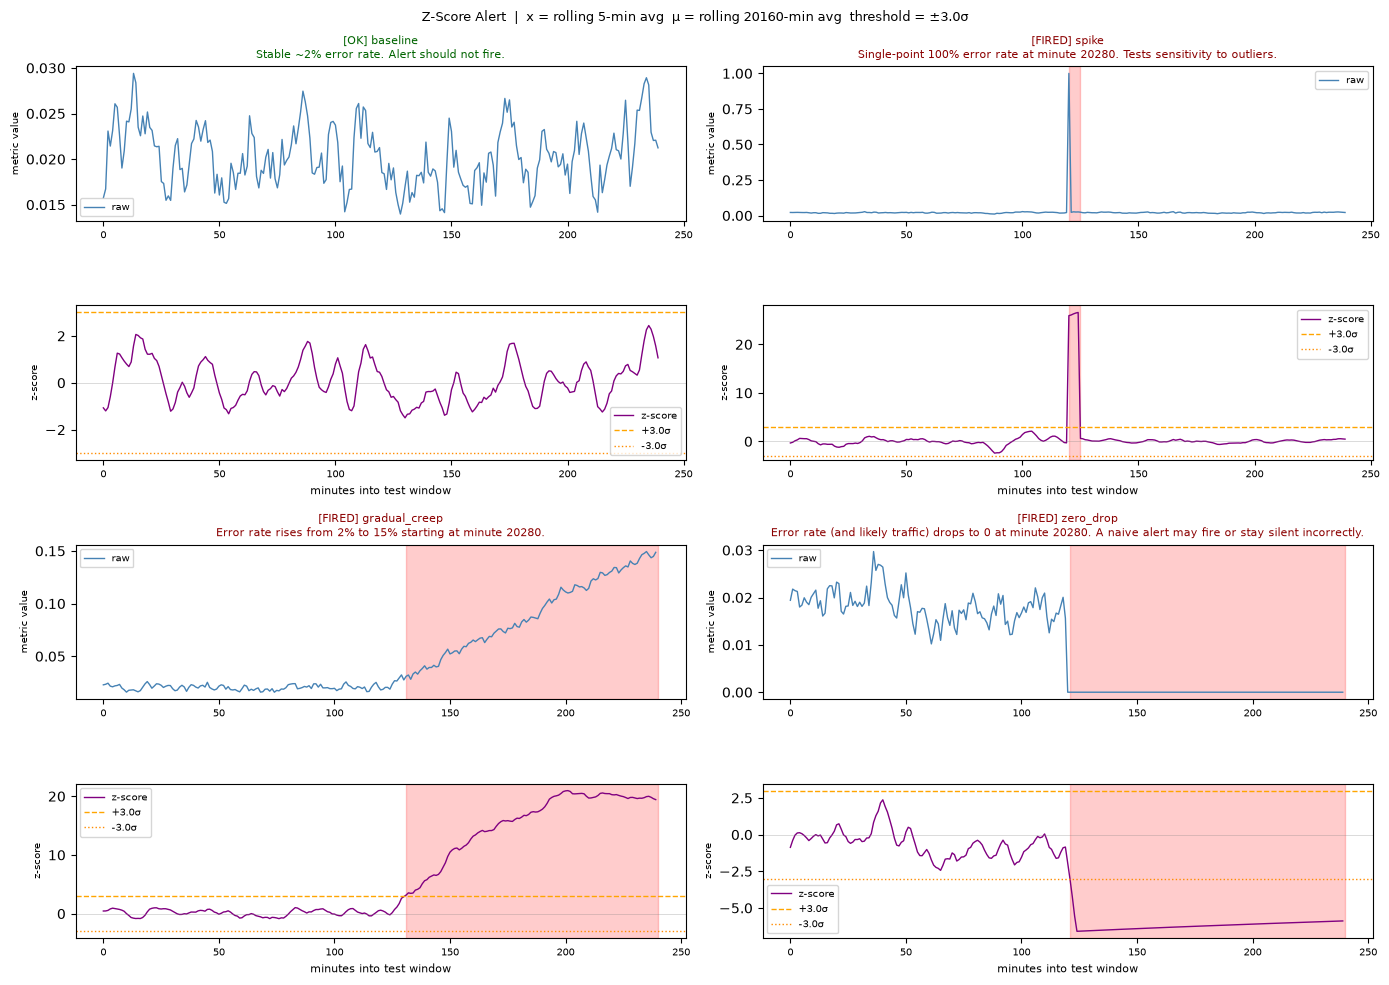

In [16]:
plot_zscore_results(zs_results, zs_rule)

### Monte Carlo simulation — z-score alert

Same as the static-threshold MC above: each scenario runs N times with different noise seeds
and reports the firing rate. Because the baseline is computed in pure Python (no Graphite
round-trips), this is fast even with 20 000-point series.

In [17]:
zs_factories = [
    lambda rng: scenarios.baseline(duration_min=TOTAL_MIN, rate=0.02, rng=rng),
    lambda rng: scenarios.spike(duration_min=TOTAL_MIN, spike_at_min=EVENT_MIN, spike_value=1.0, rng=rng),
    lambda rng: scenarios.gradual_creep(duration_min=TOTAL_MIN, creep_start_min=EVENT_MIN, end_rate=0.15, rng=rng),
    lambda rng: scenarios.zero_drop(duration_min=TOTAL_MIN, drop_at_min=EVENT_MIN, rng=rng),
]

In [18]:
zs_mc_results = monte_carlo_zscore(zs_rule, zs_factories, n=100, seed=42)

In [19]:
zscore_mc_summary(zs_mc_results)

,scenario,n_runs,fire_rate,median_first_fire_test_min
0,baseline,100,0.0,NaN
1,spike,100,1.0,120.0
2,gradual_creep,100,1.0,131.0
3,zero_drop,100,1.0,122.0


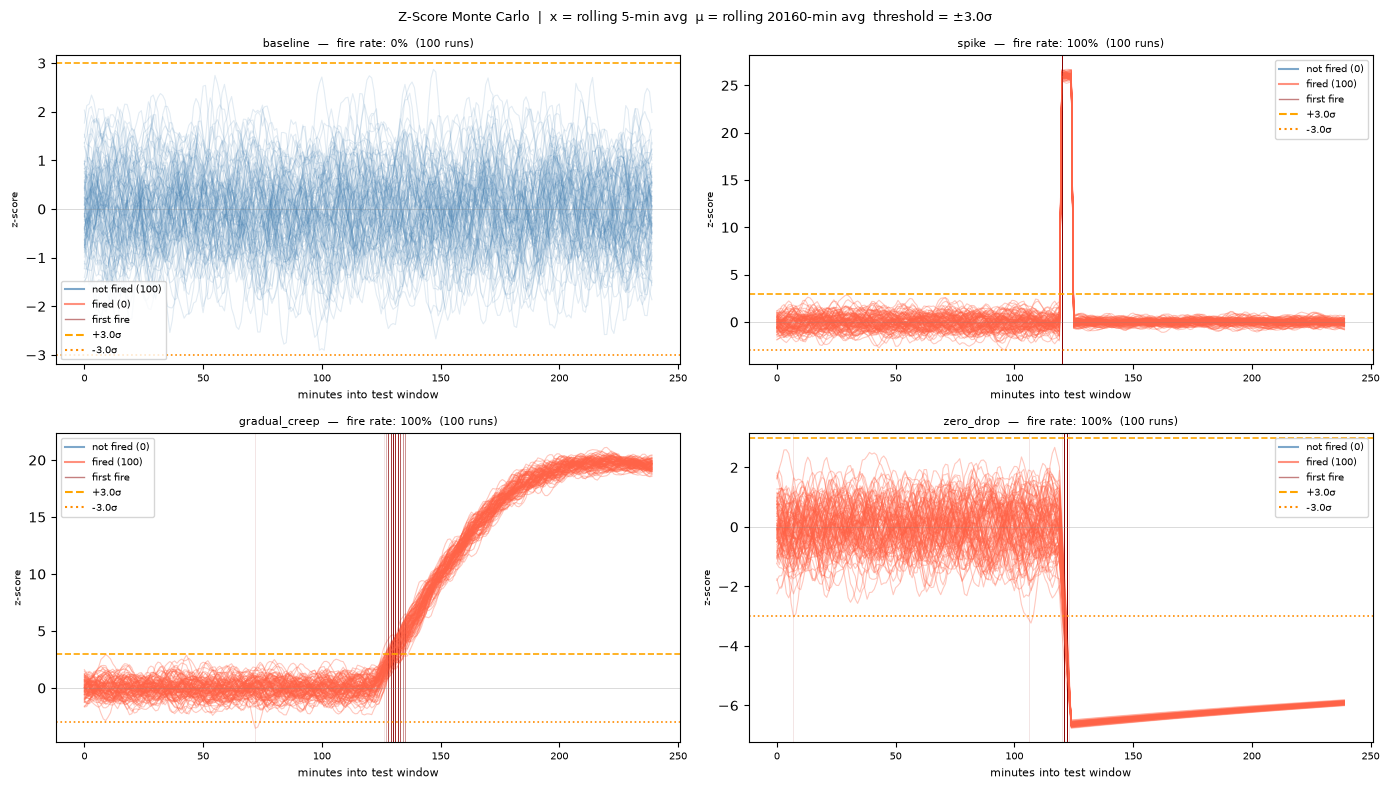

In [20]:
plot_zscore_mc(zs_mc_results, zs_rule)

---
## Parameter sweep — finding a sane operating point

The MC runs above use fixed parameters. This sweep runs 100 simulations for every combination
of `sigma_threshold` and `for_duration_minutes` and plots:

- **FPR** (left): fire rate on baseline scenarios — want this near 0%
- **TPR** (right): fire rate on anomaly scenarios — want this near 100%

`for_duration_minutes` requires N *consecutive* minutes above the threshold before the alert
fires, which is the primary lever against transient noise causing pages.

The `noisy_baseline` scenario uses higher autocorrelated noise (φ=0.92, std=0.012) to stress-test
the FPR; the clean `baseline` scenario is included for comparison.

In [21]:
from metrics_simulation import parameter_sweep, plot_parameter_sweep

sweep_factories = {
    # --- baseline (FPR scenarios) ---
    "baseline":       lambda rng: scenarios.baseline(duration_min=TOTAL_MIN, rate=0.02, rng=rng),
    "noisy_baseline": lambda rng: scenarios.noisy_baseline(duration_min=TOTAL_MIN, rate=0.02, rng=rng),
    # --- anomaly (TPR scenarios) ---
    "spike":          lambda rng: scenarios.spike(duration_min=TOTAL_MIN, spike_at_min=EVENT_MIN, spike_value=1.0, rng=rng),
    "gradual_creep":  lambda rng: scenarios.gradual_creep(duration_min=TOTAL_MIN, creep_start_min=EVENT_MIN, end_rate=0.15, rng=rng),
    "zero_drop":      lambda rng: scenarios.zero_drop(duration_min=TOTAL_MIN, drop_at_min=EVENT_MIN, rng=rng),
}

sweep_df = parameter_sweep(
    sweep_factories,
    sigma_values=[2.0, 2.5, 3.0, 3.5, 4.0],
    for_duration_values=[1, 3, 5, 10, 15],
    short_window=5,
    long_window=BURN_IN_MIN,
    burn_in_min=BURN_IN_MIN,
    n=100,
    seed=42,
)

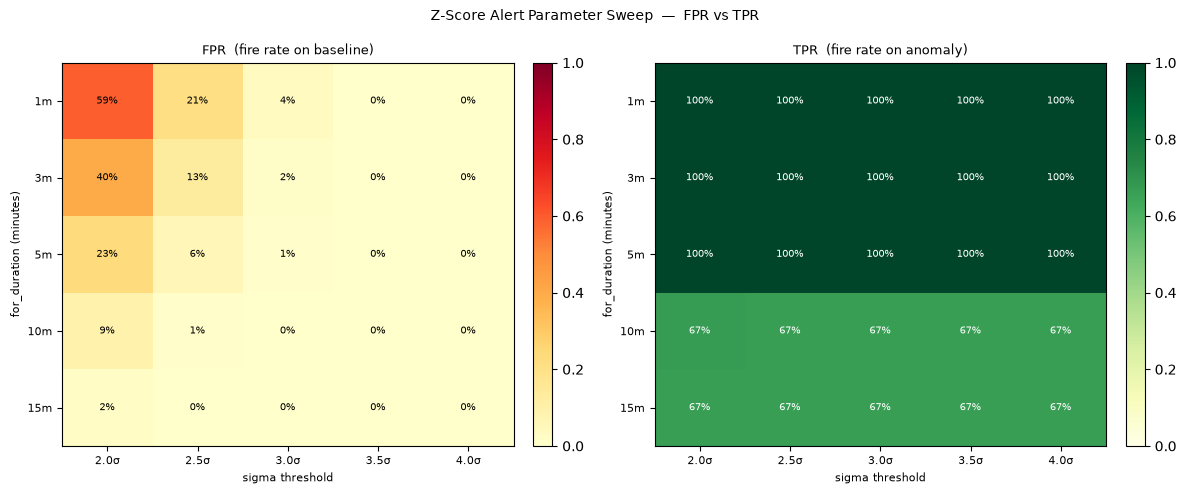

In [22]:
plot_parameter_sweep(
    sweep_df,
    baseline_scenarios=["baseline", "noisy_baseline"],
    anomaly_scenarios=["spike", "gradual_creep", "zero_drop"],
)

### Reading the heat maps

Look for the cell where:
- **FPR ≈ 0%** (left map is white/pale)
- **TPR ≈ 100%** (right map is dark green)

That intersection is your operating point. A good starting target:

| Parameter | Recommended starting value |
|-----------|---------------------------|
| `sigma_threshold` | 3.0 |
| `for_duration_minutes` | 3–5 |

Increase `for_duration_minutes` to reduce noise at the cost of detection latency.
Increase `sigma_threshold` to suppress FPR on noisier metrics, but watch the gradual-creep TPR drop.

In [23]:
# Tidy view: pick rows that meet your targets
fpr_limit = 0.02   # tolerate at most 2% false positive rate
tpr_floor = 0.80   # require at least 80% true positive rate

baseline_scens = ["baseline", "noisy_baseline"]
anomaly_scens  = ["spike", "gradual_creep", "zero_drop"]

fpr = (
    sweep_df[sweep_df["scenario"].isin(baseline_scens)]
    .groupby(["sigma_threshold", "for_duration_minutes"])["fire_rate"]
    .mean()
    .rename("fpr")
)
tpr = (
    sweep_df[sweep_df["scenario"].isin(anomaly_scens)]
    .groupby(["sigma_threshold", "for_duration_minutes"])["fire_rate"]
    .mean()
    .rename("tpr")
)

candidates = (
    fpr.to_frame()
    .join(tpr)
    .query("fpr <= @fpr_limit and tpr >= @tpr_floor")
    .sort_values(["fpr", "tpr"], ascending=[True, False])
    .reset_index()
)
candidates

,sigma_threshold,for_duration_minutes,fpr,tpr
0,3.5,1,0.000,1.0
1,3.5,3,0.000,1.0
2,3.5,5,0.000,1.0
3,4.0,1,0.000,1.0
4,4.0,3,0.000,1.0
5,4.0,5,0.000,1.0
6,3.0,5,0.010,1.0
7,3.0,3,0.015,1.0
